<a href="https://colab.research.google.com/github/Car27VeP/Data_Science_Projects/blob/main/Simulador_de_Carga_y_Latencia_de_Servidores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea
Imagina que eres el Data Scientist de una plataforma de juegos en Malta. Tienes 3 servidores distribuyendo el tráfico de miles de jugadores. Tu misión es detectar cuál es el más ineficiente bajo estrés.

Tu Misión (30 min):
1. Generación de Datos de Alta Frecuencia:Genera un DataFrame con 1,000 registros de logs de servidor.Columnas: server_id (S1, S2, S3), latency_ms (usa np.random.normal con diferentes medias para cada uno), y player_count (entre 50 y 500).

2. Identificación de "Cuellos de Botella":Crea una columna llamada efficiency_score calculada como: $efficiency\_score = \frac{player\_count}{latency\_ms}$.Entre más jugadores atienda con menos latencia, mejor es el servidor.Análisis de Outliers (Lo más difícil):

3. Identifica los registros donde la latencia sea 2 desviaciones estándar por encima de la media de ese servidor específico. Estos son tus "picos de lag".

4. Visualización Pro:Haz un Scatter Plot (gráfico de dispersión) donde el eje X sea player_count, el eje Y sea latency_ms y los colores representen cada server_id.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 1000

data = {
    'server_id': np.random.choice(['S1', 'S2', 'S3'], n),
    'player_count': np.random.randint(50, 501, n)
}
df = pd.DataFrame(data)

# Simulamos latencias diferentes (S3 es el más viejo y lento)
conditions = [
    (df['server_id'] == 'S1'),
    (df['server_id'] == 'S2'),
    (df['server_id'] == 'S3')
]
choices = [
    np.random.normal(20, 5, n), # S1: Rápido (media 20ms)
    np.random.normal(25, 7, n), # S2: Promedio (media 25ms)
    np.random.normal(45, 15, n) # S3: Viejo/Lento (media 45ms)
]
df['latency_ms'] = np.select(conditions, choices)

In [ ]:
df

,server_id,player_count,latency_ms
0,S3,296,73.446186
1,S1,436,24.686118
2,S3,292,65.888179
3,S3,80,14.263142
4,S1,89,12.869372
...,...,...,...
995,S2,76,37.755183
996,S2,223,13.781267
997,S3,99,32.124670
998,S3,248,53.493401


In [ ]:
df.describe(include='all')

,server_id,player_count,latency_ms
count,1000,1000.000000,1000.000000
unique,3,NaN,NaN
top,S1,NaN,NaN
freq,355,NaN,NaN
mean,NaN,273.861000,29.791023
std,NaN,131.845906,14.559877
min,NaN,50.000000,0.703873
25%,NaN,160.000000,19.538702
50%,NaN,275.000000,25.964664
75%,NaN,384.000000,36.923078


In [ ]:
# Efficency score
df['efficency_score'] = df['player_count']/df['latency_ms']
df.sample(5)

,server_id,player_count,latency_ms,efficency_score
991,S3,142,31.559527,4.499434
717,S1,351,17.855785,19.657494
307,S3,410,14.898320,27.519882
406,S1,452,22.091033,20.460791
147,S3,228,55.078299,4.139561


In [ ]:
df.describe()

,player_count,latency_ms,efficency_score
count,1000.000000,1000.000000,1000.000000
mean,273.861000,29.791023,11.685679
std,131.845906,14.559877,15.633246
min,50.000000,0.703873,0.741688
25%,160.000000,19.538702,5.540011
50%,275.000000,25.964664,9.282391
75%,384.000000,36.923078,15.033021
max,499.000000,86.260845,430.475084


In [ ]:
df

,server_id,player_count,latency_ms,efficency_score
0,S3,296,73.446186,4.030162
1,S1,436,24.686118,17.661748
2,S3,292,65.888179,4.431751
3,S3,80,14.263142,5.608862
4,S1,89,12.869372,6.915644
...,...,...,...,...
995,S2,76,37.755183,2.012969
996,S2,223,13.781267,16.181386
997,S3,99,32.124670,3.081744
998,S3,248,53.493401,4.636086


In [ ]:
# Eficiencia del promedio global

promedio_global = df['efficency_score'].mean()

comparativo = df.groupby('server_id')['efficency_score'].mean() / promedio_global

comparativo

,efficency_score
server_id,
S1,1.197819
S2,1.030467
S3,0.748720


Si el resultado es > 1, el servidor es mejor que el promedio (¡Es bueno!).

Si el resultado es < 1, el servidor está por debajo de la media (Necesita revisión).

In [ ]:
# Identificar los picos de latencia.

Q1 = df['latency_ms'].quantile(0.25)
Q3 = df['latency_ms'].quantile(0.75)
IQR = Q3 - Q1
limitie_superior = Q3 + 1.5 * IQR

df[df['latency_ms'] > limitie_superior]

,server_id,player_count,latency_ms,efficency_score
0,S3,296,73.446186,4.030162
2,S3,292,65.888179,4.431751
13,S3,53,67.721731,0.782614
42,S3,50,67.413769,0.741688
58,S3,456,68.253745,6.680952
118,S3,138,67.323530,2.049803
130,S3,72,65.857839,1.093264
156,S3,469,68.464043,6.850311
189,S3,373,63.160359,5.905603
212,S3,352,68.096111,5.169164


El servidor 3 es que unico que generó picos de lag y outliers. Es necesario cambiar ese servidor.

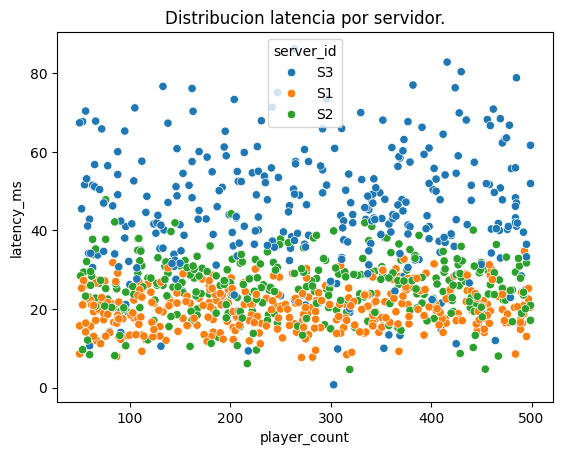

In [ ]:
# Visualizacion
sns.scatterplot(data=df, x = 'player_count', y='latency_ms', hue= 'server_id')
plt.title("Distribucion latencia por servidor.")
plt.show()